# Import Libraries

In [1]:
import os
import json
import cv2
import numpy as np
from pathlib import Path

import cv2
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import random

import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score
)

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

# Palm Frame Extraction and ROI Detection

In [2]:
def extract_uniform_frames(
    video_path: Path,
    out_dir: Path,
    n_frames=5,
    size=(224, 224),
    sample_from_last_seconds: float = None  
):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0
    fps     = cap.get(cv2.CAP_PROP_FPS) or 30          # fallback 30 fps

    if total == 0:
        cap.release()
        return []

    if sample_from_last_seconds is not None:
        last_n_frames = int(sample_from_last_seconds * fps)
        start_frame   = max(0, total - last_n_frames)
    else:
        start_frame   = 0         

    end_frame = total - 1         

    
    indices = [
        min(end_frame, max(start_frame,
            int(start_frame + (end_frame - start_frame) * (i + 0.5) / n_frames)))
        for i in range(n_frames)
    ]

    out_dir.mkdir(parents=True, exist_ok=True)
    saved = []

    for i, idx in enumerate(indices, 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame    = cv2.resize(frame, size)
        out_path = out_dir / f"frame_{i:02d}.jpg"
        cv2.imwrite(str(out_path), frame, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        saved.append(str(out_path))

    cap.release()
    return saved

In [3]:
def extract_all(
    root_dir="Data",
    n_frames=5,
    size=(224, 224),
    sample_from_last_seconds: float = 5.0   # Last 5 seconds are sampled
):
    root     = Path(root_dir)
    subjects = sorted([p for p in root.iterdir() if p.is_dir()])
    summary  = []

    for s in subjects:
        video = s / "Palm.mp4"
        if not video.exists():
            print(f"[SKIP] {s.name}: no Palm.mp4")
            summary.append((s.name, 0, "no_video"))
            continue

        frames_dir = s / "palm_frames"
        frames = extract_uniform_frames(
            video, frames_dir,
            n_frames=n_frames,
            size=size,
            sample_from_last_seconds=sample_from_last_seconds
        )
        print(f"{s.name} saved to {frames_dir}")
        summary.append((s.name, len(frames)))
    return summary

In [4]:
summary = extract_all(root_dir="Data")

ID001 saved to Data\ID001\palm_frames
ID002 saved to Data\ID002\palm_frames
ID003 saved to Data\ID003\palm_frames
ID004 saved to Data\ID004\palm_frames
ID005 saved to Data\ID005\palm_frames
ID006 saved to Data\ID006\palm_frames
ID007 saved to Data\ID007\palm_frames
ID008 saved to Data\ID008\palm_frames
ID009 saved to Data\ID009\palm_frames
ID010 saved to Data\ID010\palm_frames
ID011 saved to Data\ID011\palm_frames
ID012 saved to Data\ID012\palm_frames
ID013 saved to Data\ID013\palm_frames
ID014 saved to Data\ID014\palm_frames
ID015 saved to Data\ID015\palm_frames
ID016 saved to Data\ID016\palm_frames
ID017 saved to Data\ID017\palm_frames
ID018 saved to Data\ID018\palm_frames
ID019 saved to Data\ID019\palm_frames
ID020 saved to Data\ID020\palm_frames
ID021 saved to Data\ID021\palm_frames
ID022 saved to Data\ID022\palm_frames
ID023 saved to Data\ID023\palm_frames
ID024 saved to Data\ID024\palm_frames
ID025 saved to Data\ID025\palm_frames
ID026 saved to Data\ID026\palm_frames
ID027 saved 

In [5]:
def show_subject_frames(subject_id, root_dir):
    s = Path(root_dir) / subject_id
    frames_dir = s / "palm_frames"
    frames = sorted(frames_dir.glob("frame_*.jpg"))
    if not frames:
        print("No frames found for", subject_id)
        return
    imgs = [Image.open(p).convert("RGB") for p in frames]
    n = len(imgs)
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, im in enumerate(imgs, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(im)
        plt.axis("off")
        plt.title(frames[i-1].name)
    plt.suptitle(f"{subject_id} Palm Frames")
    plt.show()


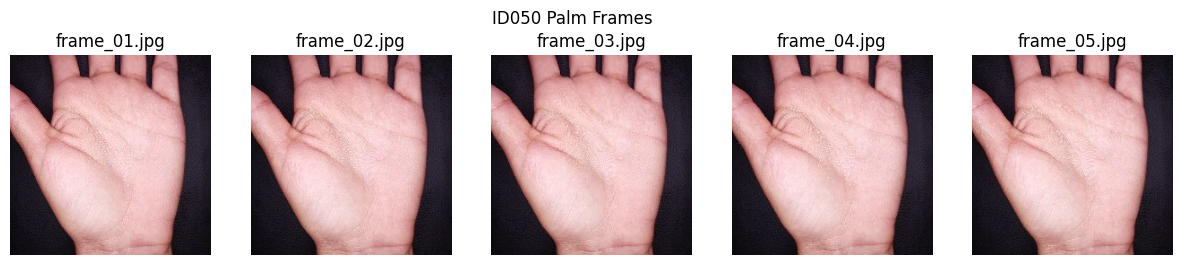

In [6]:
show_subject_frames("ID050", root_dir="Data")

Palm ROI — fixed geometric centre crop
For anemia detection the ROI is always the central palm region,
NOT the brightest spot. We use a fixed proportional box anchored
to the image centre.

In [7]:
CENTRE_X = 0.50
CENTRE_Y = 0.48   
ROI_FRACTION = 0.38  

In [8]:
def get_palm_centre_roi(img_rgb, roi_size=None):
    h, w = img_rgb.shape[:2]

    cx = int(w * CENTRE_X)
    cy = int(h * CENTRE_Y)

    if roi_size is not None:
        half = roi_size // 2
    else:
        half = int(min(h, w) * ROI_FRACTION / 2)

    # clamp
    half = max(10, half)
    cx   = max(half, min(cx, w - half))
    cy   = max(half, min(cy, h - half))

    return cx, cy, half

In [9]:
def draw_and_extract_roi(frame_path, roi_size=None):
    img_cv = cv2.imread(str(frame_path))
    if img_cv is None:
        return None, None

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    cx, cy, half = get_palm_centre_roi(img_rgb, roi_size)

    left, upper = cx - half, cy - half
    right, lower = cx + half, cy + half

    img_with_box = img_rgb.copy()
    cv2.rectangle(img_with_box,
                  (left, upper), (right, lower),
                  (0, 0, 0), 3)

    roi_img = img_rgb[upper:lower, left:right]
    return img_with_box, roi_img

In [ ]:
def save_all_rois(root_dir="Data", roi_size=None, out_size=(224, 224)):
    root     = Path(root_dir)
    subjects = sorted([p for p in root.iterdir() if p.is_dir()])

    for s in subjects:
        frames_dir = s / "palm_frames"
        roi_dir    = s / "Palm_ROI"
        frames     = sorted(frames_dir.glob("frame_*.jpg"))

        if len(frames) < 3:
            print(f"{s.name}: fewer than 3 frames, skipping")
            continue

        roi_dir.mkdir(parents=True, exist_ok=True)

        # Select only the 3rd frame
        f = frames[2]
        _, roi = draw_and_extract_roi(f, roi_size)
        if roi is None or roi.size == 0:
            print(f"{s.name}: ROI extraction failed for {f.name}")
            continue

        roi_resized = cv2.resize(
            cv2.cvtColor(roi, cv2.COLOR_RGB2BGR),
            out_size, interpolation=cv2.INTER_AREA
        )
        cv2.imwrite(str(roi_dir / f.name), roi_resized,
                    [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        print(f"{s.name}: saved 3rd frame ROI to {roi_dir}")


In [11]:
save_all_rois(root_dir="Data", out_size=(224, 224))

ID001: saved 3rd frame ROI to Data\ID001\Palm_ROI
ID002: saved 3rd frame ROI to Data\ID002\Palm_ROI
ID003: saved 3rd frame ROI to Data\ID003\Palm_ROI
ID004: saved 3rd frame ROI to Data\ID004\Palm_ROI
ID005: saved 3rd frame ROI to Data\ID005\Palm_ROI
ID006: saved 3rd frame ROI to Data\ID006\Palm_ROI
ID007: saved 3rd frame ROI to Data\ID007\Palm_ROI
ID008: saved 3rd frame ROI to Data\ID008\Palm_ROI
ID009: saved 3rd frame ROI to Data\ID009\Palm_ROI
ID010: saved 3rd frame ROI to Data\ID010\Palm_ROI
ID011: saved 3rd frame ROI to Data\ID011\Palm_ROI
ID012: saved 3rd frame ROI to Data\ID012\Palm_ROI
ID013: saved 3rd frame ROI to Data\ID013\Palm_ROI
ID014: saved 3rd frame ROI to Data\ID014\Palm_ROI
ID015: saved 3rd frame ROI to Data\ID015\Palm_ROI
ID016: saved 3rd frame ROI to Data\ID016\Palm_ROI
ID017: saved 3rd frame ROI to Data\ID017\Palm_ROI
ID018: saved 3rd frame ROI to Data\ID018\Palm_ROI
ID019: saved 3rd frame ROI to Data\ID019\Palm_ROI
ID020: saved 3rd frame ROI to Data\ID020\Palm_ROI


In [12]:
def debug_roi(subject_id, root_dir="Data", roi_size=None):
    frames_dir = Path(root_dir) / subject_id / "palm_frames"
    frames     = sorted(frames_dir.glob("frame_*.jpg"))

    if not frames:
        print(f"No frames found for {subject_id}")
        return

    fig, axes = plt.subplots(len(frames), 2,
                             figsize=(8, len(frames) * 3))
    if len(frames) == 1:
        axes = [axes]

    for i, fp in enumerate(frames):
        img_with_box, roi = draw_and_extract_roi(fp, roi_size)

        axes[i][0].imshow(img_with_box)
        axes[i][0].set_title(f"{fp.name}\n(black box = ROI)")
        axes[i][0].axis("off")

        if roi is not None and roi.size > 0:
            axes[i][1].imshow(roi)
            axes[i][1].set_title("Cropped ROI")
        axes[i][1].axis("off")

    plt.suptitle(subject_id, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

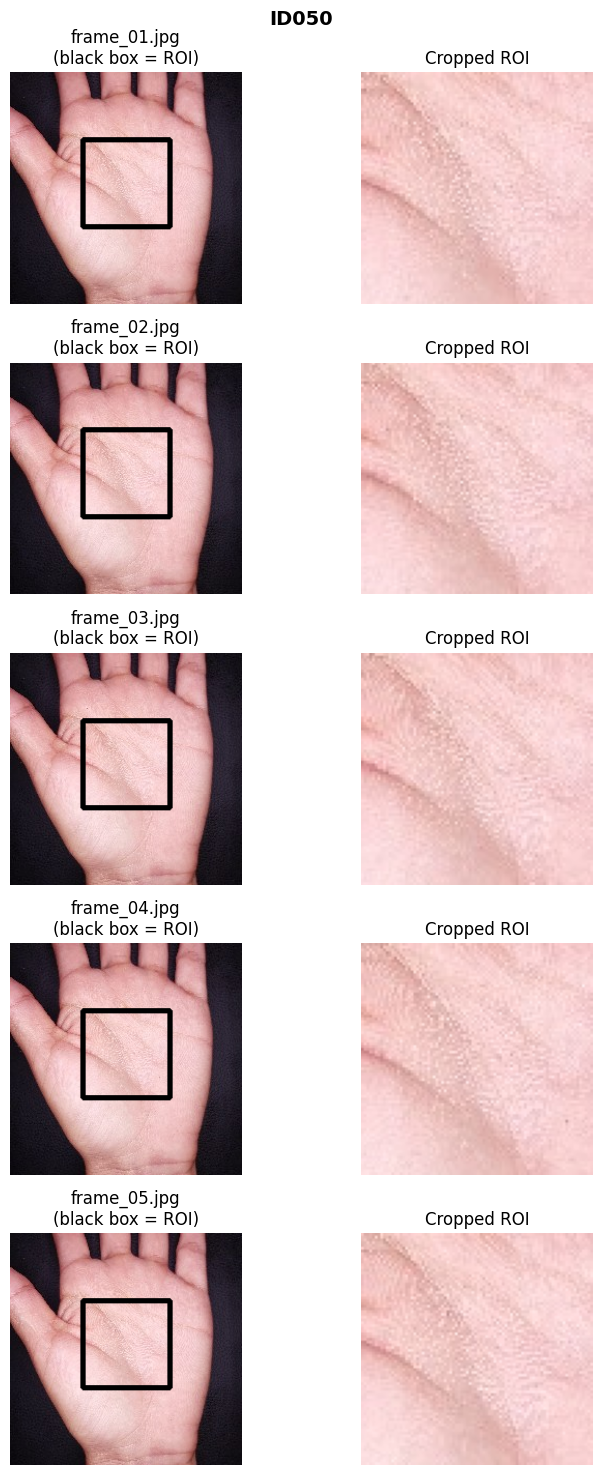

In [13]:
debug_roi(subject_id='ID050', root_dir="Data", roi_size=None)

# Nail ROI Detection & Background Removal

Nail ROI — fixed centre crop for index finger
Index finger is always in the centre of the image.

In [14]:
CX      = 0.50   # horizontal centre of finger
CY      = 0.45   # vertical centre — upper half = nail area
W_FRAC  = 0.25   # width  of crop as fraction of image width
H_FRAC  = 0.40   # height of crop as fraction of image height

In [ ]:
def roi_background(img_bgr):
    img_ycbcr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    
    lower_skin = np.array([0, 133, 77],  dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    
    skin_mask = cv2.inRange(img_ycbcr, lower_skin, upper_skin)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_CLOSE, kernel)
    skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN,  kernel)
    
    # Fill holes so nail plate isn't masked out
    contours, _ = cv2.findContours(skin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        filled_mask = np.zeros_like(skin_mask)
        cv2.drawContours(filled_mask, [largest], -1, 255, thickness=cv2.FILLED)
        skin_mask = filled_mask

    result = cv2.bitwise_and(img_bgr, img_bgr, mask=skin_mask)
    return result

In [16]:
def extract_nail(image_path, size=(224, 224)):
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None, None

    H, W = img.shape[:2]

    half_w = int(W * W_FRAC / 2)
    half_h = int(H * H_FRAC / 2)
    cx     = int(W * CX)
    cy     = int(H * CY)

    x1 = max(0, cx - half_w)
    y1 = max(0, cy - half_h)
    x2 = min(W, cx + half_w)
    y2 = min(H, cy + half_h)

    roi         = img[y1:y2, x1:x2]
    roi_resized = cv2.resize(roi, size, interpolation=cv2.INTER_AREA)

    # Background removal
    roi_no_bg   = roi_background (roi_resized)  

    debug = img.copy()
    cv2.rectangle(debug, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return debug, roi_resized, roi_no_bg

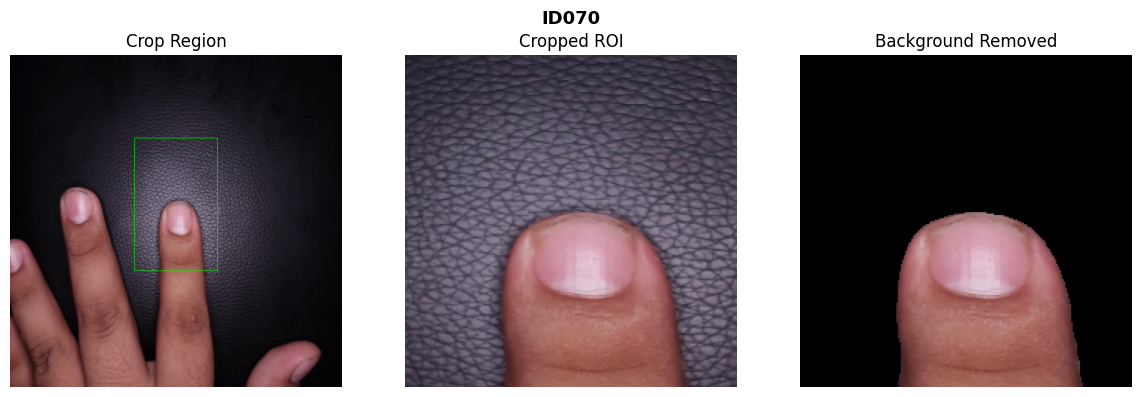

In [ ]:
def show_all(subject_path, size=(224, 224)):
    s = Path(subject_path)
    nail_path = s / "Nail.jpg"
    if not nail_path.exists():
        nail_path = s / "nail.jpg"
    if not nail_path.exists():
        print(f"{s.name}: no Nail.jpg")
        return

    debug_img, roi, roi_no_bg = extract_nail(nail_path, size=size)
    if debug_img is None:
        print(f"{s.name} Failed to extract nail ROI")
        return

    # Show all 3
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Crop Region")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Cropped ROI")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(roi_no_bg, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Background Removed")
    axes[2].axis("off")

    plt.suptitle(s.name, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_all("Data/ID070", size=(224, 224))

In [ ]:
def save_all(root_dir="Data", size=(224, 224)):
    root     = Path(root_dir)
    subjects = sorted([p for p in root.iterdir() if p.is_dir()])
    skipped  = 0
    failed   = 0

    for s in subjects:
        nail_path = s / "Nail.jpg"
        if not nail_path.exists():
            nail_path = s / "nail.jpg"
        if not nail_path.exists():
            print(f"{s.name}: No Nail.jpg")
            skipped += 1
            continue

        _, _, roi_no_bg = extract_nail(nail_path, size=size)  # ← use bg removed
        if roi_no_bg is None:
            print(f"{s.name} failed to extract nail ROI")
            failed += 1
            continue

        cv2.imwrite(str(s / "nail_roi.jpg"), roi_no_bg,
                    [int(cv2.IMWRITE_JPEG_QUALITY), 90])
        print(f"{s.name} saved to {s}/nail_roi.jpg")


In [19]:
save_all(root_dir="Data")

ID001 saved to Data\ID001/nail_roi.jpg
ID002 saved to Data\ID002/nail_roi.jpg
ID003 saved to Data\ID003/nail_roi.jpg
ID004 saved to Data\ID004/nail_roi.jpg
ID005 saved to Data\ID005/nail_roi.jpg
ID006 saved to Data\ID006/nail_roi.jpg
ID007 saved to Data\ID007/nail_roi.jpg
ID008 saved to Data\ID008/nail_roi.jpg
ID009 saved to Data\ID009/nail_roi.jpg
ID010 saved to Data\ID010/nail_roi.jpg
ID011 saved to Data\ID011/nail_roi.jpg
ID012 saved to Data\ID012/nail_roi.jpg
ID013 saved to Data\ID013/nail_roi.jpg
ID014 saved to Data\ID014/nail_roi.jpg
ID015 saved to Data\ID015/nail_roi.jpg
ID016 saved to Data\ID016/nail_roi.jpg
ID017 saved to Data\ID017/nail_roi.jpg
ID018 saved to Data\ID018/nail_roi.jpg
ID019 saved to Data\ID019/nail_roi.jpg
ID020 saved to Data\ID020/nail_roi.jpg
ID021 saved to Data\ID021/nail_roi.jpg
ID022 saved to Data\ID022/nail_roi.jpg
ID023 saved to Data\ID023/nail_roi.jpg
ID024 saved to Data\ID024/nail_roi.jpg
ID025 saved to Data\ID025/nail_roi.jpg
ID026 saved to Data\ID026